In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('bmh')

### COMBINATORIAL (Bush et al., 2015)

In [2]:
class ParentNNClass():

    def __init__(self, M = 10, s_M = 25, alpha = 1.4, m = 20, r_max = 30, time_w = 0.1):
        self.M = M          # Number of GC modules
        self.s_M = s_M      # Minimum grid scale (for geometric progression)
        self.alpha = alpha  # Common factor (for geometric progression)
        self.m = m          # Number of equally distributes spatial phases
        self.r_max = r_max  # Maximum GC firing rate (Hz)
        self.poiss_time_w = time_w # Time window in Poisson process (secs)

        # Initialize networks parameters
        self.scales = self._create_scales()
        self.phases = self._create_phases()

    def _create_scales(self):
        ''' Creates M scales according to geometric progression '''
        scales = []
        for i in np.arange(self.M, 0, -1):
            new_scale = round(self.s_M * (self.alpha ** (self.M-i)),2)
            scales.append(new_scale)
        return scales

    def _create_phases(self):
        ''' Creates m equally spaced phases from 0 to 2*pi in radians'''
        return np.linspace(0, 2 * np.pi, self.m, endpoint=False)
    
    def _gc_rate(self, a, s_i, p_ij):
        ''' Calculates GC firing rate based on cosine tuned rate function '''
        num_bracket = (a - (s_i * (p_ij / (2 * np.pi)))) / s_i
        return self.r_max * (1 + np.cos(num_bracket * 2 * np.pi)) / 2
    
    def emax_N_normalize(self, x, epsilon=0.01):
        ''' Applies E%-max algorithm and normalzation steps '''
        # E%-max algorithm: silence all values below (1-epsilon) of the maximum value
        threshold = x.max() * (1 - epsilon)
        dc_activations = np.where(x >= threshold, x, 0.0)

        # Normalize so total activity is constant across simulations
        total = dc_activations.sum()
        if total > 0:
            dc_activations = dc_activations / total
        return dc_activations


class DistanceCellModel(ParentNNClass):
    
    # Call the parent class constructor to initialize the parameters
    def __init__(self, N_dc = 12500, dc_res = 4, **kwargs):
        super().__init__(**kwargs)  # Call the parent class constructor
        self.N_dc = N_dc        # Number of distance cells
        self.dc_res = dc_res    # Spatial resolution of distance cells (cm)

        # Initialize networks parameters
        self.scales = self._create_scales()
        self.phases = self._create_phases()
        self.xdc_positions = self._create_distance_cells()
        self.W_dcs = self._compute_weight_matrix()   # We use same W matrix for both x and y axes (for a total of 200 x 2 = 400 grid cells)
        self.W_pos_readout = self.xdc_positions / self.xdc_positions.max()  # Increases linearly with displacement along axis
        self.W_neg_readout = self.W_pos_readout.copy()[::-1]              # Decreases linearly (to encode opposite direction)


    def _create_distance_cells(self):
        ''' Creates N_dc distance cell according to spatial resolution '''
        return np.arange(0, self.N_dc * self.dc_res, self.dc_res)
    
    def _compute_weight_matrix(self):
        ''' For each distance cell a, compute rate of cell j at scale i (i.e., r_ij) '''
        all_weights = []
        for curr_distance in self.xdc_positions:
            distance_weights = []
            for s_i in self.scales:
                for p_ij in self.phases:
                    r_ij = self._gc_rate(curr_distance, s_i, p_ij)
                    distance_weights.append(r_ij)
            all_weights.append(distance_weights)
        return np.array(all_weights)
    
    def _gc_spikes(self, a):
        ''' Given current 2D position a, calculate GC spikes for all GCs in our network along axes x and y
            Returns a 2D array of shape (2, M*m) = (axes, modules * phases) with the number of spikes for each GC
        '''
        x_gc_spikes = []
        y_gc_spikes = []
        for s_i in self.scales:
            for p_i in self.phases:
                r_ix = self._gc_rate(a[0], s_i, p_i) # FR at x-axis
                r_iy = self._gc_rate(a[1], s_i, p_i) # FR at y-axis
                spikes_ix = np.random.poisson(lam = self.poiss_time_w * r_ix)
                spikes_iy = np.random.poisson(lam = self.poiss_time_w * r_iy)
                #print(f"GC at phase {p_ij} with rate {np.round(r_ij)}: spikes: {spikes_ij}")
                x_gc_spikes.append(spikes_ix)
                y_gc_spikes.append(spikes_iy)
        return np.array([x_gc_spikes, y_gc_spikes])

    def forward(self, a, b):
        ''' Given current 2D position a and target position b, apply forward pass by 
            1) calculating GC spikes
            2) multiplying it with the network weights
            3) applying E%-max algorithm & normalization step
        '''

        # 1. Calculate spikes for all GCs in our network start & goal positions
        start_gc_activations = self._gc_spikes(a)
        goal_gc_activations = self._gc_spikes(b)

        # 2. Compute forward passes
        start_xdc_activations = self.emax_N_normalize(self.W_dcs @ start_gc_activations[0])
        start_ydc_activations = self.emax_N_normalize(self.W_dcs @ start_gc_activations[1])
        goal_xdc_activations = self.emax_N_normalize(self.W_dcs @ goal_gc_activations[0])
        goal_ydc_activations = self.emax_N_normalize(self.W_dcs @ goal_gc_activations[1])

        # 3. Read-out cells
        x_read_out_one = self.W_neg_readout @ start_xdc_activations + self.W_pos_readout @ goal_xdc_activations
        x_read_out_two = self.W_pos_readout @ start_xdc_activations + self.W_neg_readout @ goal_xdc_activations
        x_read_out_diff = x_read_out_one - x_read_out_two
        
        y_read_out_one = self.W_neg_readout @ start_ydc_activations + self.W_pos_readout @ goal_ydc_activations
        y_read_out_two = self.W_pos_readout @ start_ydc_activations + self.W_neg_readout @ goal_ydc_activations
        y_read_out_diff = y_read_out_one - y_read_out_two

        decoded_position = np.array([x_read_out_diff, y_read_out_diff]) * (self.xdc_positions.max()/2) # Convert back to cm - need division to account for four weights
        return decoded_position
    
  
dc_model = DistanceCellModel()
print(dc_model.forward(a=[250, 250], b=[258, 258]))
# Print different edge cases
#print(dc_model.forward(a=[0, 0], b=[500, 500]))
#print(dc_model.forward(a=[500, 500], b=[0, 0]))
#print(dc_model.forward(a=[250, 250], b=[250, 250]))
#print(dc_model.forward(a=[0, 500], b=[500, 0]))

[7.99740042 9.99367766]


In [8]:
1 / np.exp(0.3 * 0)

1.0

In [13]:
class VectorCellModel(ParentNNClass):

    def __init__(self, N_vc = 1250, arena_max = 50000, **kwargs):
        super().__init__(**kwargs)  # Call the parent class constructor
        self.N_vc = N_vc    # Number of vector cells per array (x or y, pos or neg)
        self.arena_max = arena_max  # cm

        # Initialize networks parameters
        self.scales = self._create_scales()
        self.phases = self._create_phases()
        self.xvc_pos = self._create_vector_cells(direction='positive')
        self.xvc_neg = self._create_vector_cells(direction='negative')
        self.xvcs = np.concatenate((self.xvc_pos, self.xvc_neg))
        self.yvc_pos = self._create_vector_cells(direction='positive')
        self.yvc_neg = self._create_vector_cells(direction='negative')
        self.yvcs = np.concatenate((self.yvc_pos, self.yvc_neg))
        self.Wpos = self._compute_weight_matrix(direction='positive')   
      #  self.Wneg = self._compute_weight_matrix(direction='negative')

    def _create_vector_cells(self, direction='positive'):
        ''' Pseudo-exponential distribution of translation vectors encoded by vector cells. '''
        linear = np.linspace(0, 1, self.N_vc)
        k = 5  # controls steepness - tune this
        xvc_positions = self.arena_max * (np.exp(k * linear) - 1) / (np.exp(k) - 1)
        if direction == 'negative':
            xvc_positions = -xvc_positions
        return xvc_positions
    
    def _compute_weight_matrix(self, direction):
        ''' Connectivity is based on unwrapped phase difference between two grid cell pairs. Activity only 
            propagates to vector cell if such phase difference matches the vector cell's preferred translation vector.
        '''
        
        # Initialize weights to zero
        all_weights = np.zeros((self.N_vc, self.M * self.m * self.m))

        # For each GC module, iterate over pairs of GCs...
        synapse_lookup = 2868
        synapse_index = -1
        for s_i in self.scales:
            for p_j in self.phases: # GC1
                for p_k in self.phases: # GC2
                    synapse_index += 1
                    if p_j == p_k:
                        continue  
                    else:
                        # Iterate over unwrapped phase differences to calculate displacements
                        if synapse_lookup is not None and synapse_index == synapse_lookup:
                            print('---Scale:', s_i, 'Phase 1:', p_j, 'Phase 2:', p_k, 'p_2 - p_1:', p_k - p_j, 'distance:', (p_k - p_j) * s_i / (2 * np.pi))
                            print('---Synapse index:', synapse_index)
                        n = 0
                        delta_p = (p_k - p_j) % (2 * np.pi) if direction == 'positive' else (p_j - p_k) % (2 * np.pi)
                        d = ((delta_p / (2 * np.pi)) + n) * s_i
                        n_synapses = 0
                        while (d < self.arena_max):
                         #   print(f'For n={n}, d={d}')
                            
                            # Compute the index of the vector cell that corresponds to this displacement
                            vc_index = np.argmin(np.abs(self.xvc_pos - d))
                            vc_distance = np.abs(self.xvc_pos[vc_index] - d)

                            # Only connect if within half the local VC spacing
                         #  local_spacing = (self.xvc_pos[vc_index + 1] - self.xvc_pos[vc_index]) / 2 if vc_index < self.N_vc - 1 else (self.xvc_pos[vc_index] - self.xvc_pos[vc_index - 1]) / 2

                            if vc_distance <= 1:
#                                if synapse_lookup is not None and synapse_index == synapse_lookup:
#                                    print(f'For n={n}, d={d}, vc_index={vc_index}, vc_pos={self.xvc_pos[vc_index]} ... +1 at {synapse_index}!')

                            # Update the weight matrix for this vector cell and grid cell pair
                                all_weights[vc_index, synapse_index] = 1 / np.exp(0.05 * n_synapses)
                                n_synapses += 1

                            # Update variables
                            n += 1
                            delta_p = (p_k - p_j) % (2 * np.pi) if direction == 'positive' else (p_j - p_k) % (2 * np.pi)
                            d = ((delta_p / (2 * np.pi)) + n) * s_i
        # Normalize so no single GC pair dominates the weight matrix
      #  all_weights /= all_weights.sum(axis=1, keepdims=True) + 1e-10  # Add a small constant to avoid division by zero
      #  print(synapse_index)
        return np.array(all_weights)

    def _gc_pair_spikes(self, a, b):
        ''' Given current position a and target position b, calculate multiplied number of spikes for each GC pair
            Returns a 2D array of shape (2, M*m*m) = (axes, modules * phases * phases) 
        '''
        # For each GC module, iterate over pairs of GCs...
        x_gc_spikes = []
        y_gc_spikes = []
        synapse_index = -1
        for s_i in self.scales:
            for p_j in self.phases: # GC1
                for p_k in self.phases: # GC2
                    synapse_index += 1

                    # Obtain GC1 spikes for start position a
                    r_jx = self._gc_rate(a[0], s_i, p_j) 
                    r_jy = self._gc_rate(a[1], s_i, p_j)
                    spikes_jx = r_jx# np.random.poisson(lam = self.poiss_time_w * r_jx)
                    spikes_jy = r_jy# np.random.poisson(lam = self.poiss_time_w * r_jy)

                    # Obtain GC2 spikes for target position b
                    r_kx = self._gc_rate(b[0], s_i, p_k) 
                    r_ky = self._gc_rate(b[1], s_i, p_k)
                    spikes_kx = r_kx# np.random.poisson(lam = self.poiss_time_w * r_kx)
                    spikes_ky = r_ky# np.random.poisson(lam = self.poiss_time_w * r_ky)

                    # Multiply the spikes together
                    x_gc_spikes.append(spikes_jx * spikes_kx)
                    y_gc_spikes.append(spikes_jy * spikes_ky)

                    #if spikes_jx * spikes_kx > 800:
#                    print(f"S.I: {synapse_index} GC pair (s_i={s_i}, p_j dist={p_j * s_i / (2 * np.pi)}, p_k dist={p_k * s_i / (2 * np.pi)}): spikes_jx={spikes_jx}, spikes_kx={spikes_kx}, multiplied={spikes_jx * spikes_kx}")
#        print('Total number of GC pairs:', synapse_index)
        return np.array([x_gc_spikes, y_gc_spikes])
    
    def forward(self, a, b):
        ''' Given current 2D position a and target position b, apply forward pass by 
            1) calculating GC spikes
            2) multiplying it with the network weights
            3) applying E%-max algorithm & normalization step
        '''

        # 1. Calculate spikes for all GCs in our network start & goal positions
#        print(f'Calculating GC spikes for start position a={a} and goal position b={b}')
        gc_pos_activations = self._gc_pair_spikes(a, b)
       # gc_neg_activations = self._gc_pair_spikes(b, a) # Simply swap start and goal positions to get negative translation vectors

        # 2. Compute forward passes
#        print('gc_pos_activations[0]', gc_pos_activations[0])

        synapse_index = -1
        for s_i in self.scales:
            for p_j in self.phases: # GC1
                for p_k in self.phases: # GC2
                    synapse_index += 1
                    W_inds = np.where(self.Wpos[:,synapse_index]>0)
                    print('SI=', synapse_index,'GC act=', gc_pos_activations[0][synapse_index], 'with W pos inds=', W_inds, 'W=', self.Wpos[W_inds,synapse_index])
                    print('--+-Scale:', s_i, 'Phase 1:', p_j, 'Phase 2:', p_k, 'p_2 - p_1:', p_k - p_j, 'distance:', (p_k - p_j) * s_i / (2 * np.pi))


        xvc_pos_activations = self.Wpos @ gc_pos_activations[0]
       # xvc_neg_activations = self.Wneg @ gc_neg_activations[0]
        yvc_pos_activations = self.Wpos @ gc_pos_activations[1]
       # yvc_neg_activations = self.Wneg @ gc_neg_activations[1]

#        print('xvc_pos_activations:', xvc_pos_activations)
        xvc_pos_activations_normd = self.emax_N_normalize(xvc_pos_activations)
        yvc_pos_activations_normd = self.emax_N_normalize(yvc_pos_activations)
#        print('normd xvc_pos_activations_normd:', xvc_pos_activations_normd)
        for nomd_idx, nomd in enumerate(xvc_pos_activations_normd):
            print(f'For nomd_idx={nomd_idx}, encoding={self.xvc_pos[nomd_idx]}, orgl activation={xvc_pos_activations[nomd_idx]}, normd activation={nomd}')

     #   print(f'X VC pos activations: {xvc_pos_activations}')
     #   for pos in xvc_pos_activations:
     #       print(f'Activation: {pos}, Index: {np.where(xvc_pos_activations == pos)[0][0]}, VC Position: {self.xvc_pos[np.where(xvc_pos_activations == pos)[0][0]]}')
        xvc_activations = xvc_pos_activations_normd #self.emax_N_normalize(np.concatenate((xvc_pos_activations, xvc_neg_activations)))
        yvc_activations = yvc_pos_activations_normd #self.emax_N_normalize(np.concatenate((yvc_pos_activations, yvc_neg_activations)))

        # 3. Decode translation vector
        x_read_out = self.xvc_pos @ xvc_activations
        y_read_out = self.yvc_pos @ yvc_activations
        translation_vector = np.array([x_read_out, y_read_out])
        return translation_vector


vc_model = VectorCellModel()
tr_vec = vc_model.forward(a=[250, 250], b=[280, 270])
print('Expected translation vector around [20, 20]. Model translation vector:', tr_vec)
print(vc_model.xvc_pos[:10])   # first 10 vc positions
print(vc_model.xvc_pos[-10:])  # last 10 vc positions
print(vc_model.Wpos.sum(axis=1)[:10])   # connections to first 10 VCs
print(vc_model.Wpos.sum(axis=1)[-10:])  # connections to last 10 VCs


---Scale: 263.53 Phase 1: 0.9424777960769379 Phase 2: 2.5132741228718345 p_2 - p_1: 1.5707963267948966 distance: 65.8825
---Synapse index: 2868
SI= 0 GC act= 589.0576474687275 with W pos inds= (array([], dtype=int64),) W= []
--+-Scale: 25.0 Phase 1: 0.0 Phase 2: 0.0 p_2 - p_1: 0.0 distance: 0.0
SI= 1 GC act= 714.5033635316145 with W pos inds= (array([   1,   19,   35,   51,   65,   79,   92,  105,  116,  128,  149,
        159,  168,  195,  203,  219,  234,  241,  248,  255,  274,  280,
        286,  303,  319,  324,  329,  348,  357,  374,  378,  382,  386,
        390,  405,  412,  419,  439,  442,  463,  466,  477,  493,  498,
        503,  515,  522,  533,  552,  554,  556,  558,  598,  603,  611,
        622,  625,  628,  631,  648,  664,  679,  685,  700,  712,  743,
        762,  790,  818,  840,  850,  859,  866,  870,  888,  921,  926,
        934,  955,  957,  959,  986,  993, 1011, 1018, 1026, 1029, 1057,
       1068, 1080, 1094, 1109, 1115, 1119, 1126, 1133, 1152, 1154, 115

In [54]:
vc_model.xvcs

array([ 0.00000000e+00,  1.36053867e+00,  2.72653478e+00, ...,
       -4.95985732e+04, -4.97988849e+04, -5.00000000e+04])

In [42]:
print(vc_model.xvc_pos[:10])   # first 10 vc positions
print(vc_model.xvc_pos[-10:])  # last 10 vc positions
print(vc_model.Wpos.sum(axis=1)[:10])   # connections to first 10 VCs
print(vc_model.Wpos.sum(axis=1)[-10:])  # connections to last 10 VCs

[ 0.          1.36053867  2.72653478  4.0980102   5.47498692  6.857487
  8.24553261  9.63914598 11.03834944 12.44316543]
[48218.62166722 48413.39799869 48608.95562206 48805.29767127
 49002.42729282 49200.34764586 49399.06190218 49598.5732463
 49798.88487554 50000.        ]
[0.         0.41237113 0.41237113 0.6185567  0.82474227 1.2371134
 0.41237113 1.03092784 0.41237113 0.6185567 ]
[1.44329897 0.82474227 1.03092784 1.03092784 0.82474227 1.8556701
 1.2371134  0.6185567  1.03092784 0.6185567 ]


In [59]:
curr_xpos = 903
print('For VC position', curr_xpos)
print('Total activation:', vc_model.Wpos[curr_xpos, :].sum())
for syn_i, syn in enumerate(vc_model.Wpos[curr_xpos, :]):
    print(f"Synapse {syn_i}: {syn}")


For VC position 903
Total activation: 0.99999999999875
Synapse 0: 0.0
Synapse 1: 0.0
Synapse 2: 0.0
Synapse 3: 0.0
Synapse 4: 0.0
Synapse 5: 0.0
Synapse 6: 0.0
Synapse 7: 0.0
Synapse 8: 0.012499999999984374
Synapse 9: 0.012499999999984374
Synapse 10: 0.0
Synapse 11: 0.0
Synapse 12: 0.0
Synapse 13: 0.0
Synapse 14: 0.0
Synapse 15: 0.0
Synapse 16: 0.0
Synapse 17: 0.0
Synapse 18: 0.0
Synapse 19: 0.0
Synapse 20: 0.0
Synapse 21: 0.0
Synapse 22: 0.0
Synapse 23: 0.0
Synapse 24: 0.0
Synapse 25: 0.0
Synapse 26: 0.0
Synapse 27: 0.0
Synapse 28: 0.0
Synapse 29: 0.012499999999984374
Synapse 30: 0.012499999999984374
Synapse 31: 0.0
Synapse 32: 0.0
Synapse 33: 0.0
Synapse 34: 0.0
Synapse 35: 0.0
Synapse 36: 0.0
Synapse 37: 0.0
Synapse 38: 0.0
Synapse 39: 0.0
Synapse 40: 0.0
Synapse 41: 0.0
Synapse 42: 0.0
Synapse 43: 0.0
Synapse 44: 0.0
Synapse 45: 0.0
Synapse 46: 0.0
Synapse 47: 0.0
Synapse 48: 0.0
Synapse 49: 0.0
Synapse 50: 0.012499999999984374
Synapse 51: 0.012499999999984374
Synapse 52: 0.0
Synap

In [6]:
for vc_i, vc in enumerate(vc_model.xvc_pos):
    print(f"VC{vc_i}: {vc}")

VC0: 0.0
VC1: 1.3605386740447145
VC2: 2.726534776302122
VC3: 4.098010197750803
VC4: 5.4749869171786285
VC5: 6.85748700153554
VC6: 8.24553260628714
VC7: 9.639145975769269
VC8: 11.03834944354515
VC9: 12.443165432762889
VC10: 13.853616456514738
VC11: 15.269725118198211
VC12: 16.691514111878195
VC13: 18.11900622265058
VC14: 19.552224327007277
VC15: 20.991191393203085
VC16: 22.435930481623757
VC17: 23.886464745155337
VC18: 25.34281742955543
VC19: 26.80501187382544
VC20: 28.273071510585
VC21: 29.747019866447214
VC22: 31.22688056239565
VC23: 32.71267731416308
VC24: 34.204433932611515
VC25: 35.702174324113486
VC26: 37.20592249093555
VC27: 38.715702531622874
VC28: 40.231538641385086
VC29: 41.75345511248443
VC30: 43.28147633462493
VC31: 44.81562679534315
VC32: 46.35593108040071
VC33: 47.9024138741783
VC34: 49.455099960071294
VC35: 51.01401422088674
VC36: 52.5791816392423
VC37: 54.15062729796668
VC38: 55.728376380501366
VC39: 57.312454171304225
VC40: 58.90288605625507
VC41: 60.499697523061975
VC4

In [38]:
syn_index = 8
only_active_syns = True
print(f'Analyzing synapse index {syn_index} for VC activations:')
for vc_i, vc in enumerate(vc_model.Wpos[:,syn_index]):
    curr_xpos = round(vc_model.xvc_pos[vc_i], 2)
    if only_active_syns and not vc > 0:
        continue
    print(f"VC{vc_i}: {curr_xpos} \t synapse: {vc}")

Analyzing synapse index 8 for VC activations:
VC7: 9.64 	 synapse: 0.010309278350515464
VC25: 35.7 	 synapse: 0.010309278350515464
VC41: 60.5 	 synapse: 0.010309278350515464
VC56: 85.24 	 synapse: 0.010309278350515464
VC70: 109.7 	 synapse: 0.010309278350515464
VC84: 135.58 	 synapse: 0.010309278350515464
VC97: 160.94 	 synapse: 0.010309278350515464
VC109: 185.55 	 synapse: 0.010309278350515464
VC120: 209.17 	 synapse: 0.010309278350515464
VC142: 259.66 	 synapse: 0.010309278350515464
VC152: 284.12 	 synapse: 0.010309278350515464
VC162: 309.57 	 synapse: 0.010309278350515464
VC181: 360.84 	 synapse: 0.010309278350515464
VC198: 410.14 	 synapse: 0.010309278350515464
VC206: 434.53 	 synapse: 0.010309278350515464
VC214: 459.71 	 synapse: 0.010309278350515464
VC222: 485.71 	 synapse: 0.010309278350515464
VC229: 509.15 	 synapse: 0.010309278350515464
VC257: 609.77 	 synapse: 0.010309278350515464
VC270: 660.47 	 synapse: 0.010309278350515464
VC276: 684.77 	 synapse: 0.010309278350515464
VC28

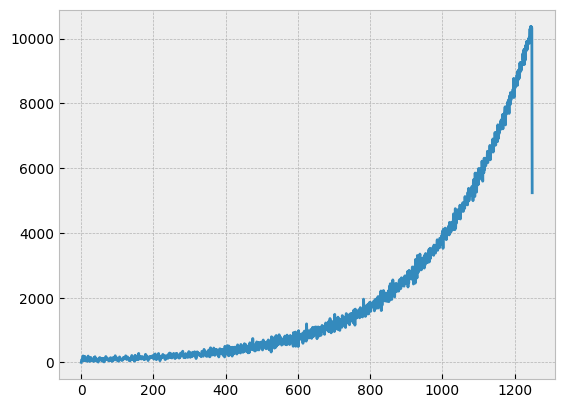

In [ ]:
plt.plot(vc_model.W.sum(axis=1))
plt.show()

In [ ]:
for w in vc_model.Wpos[-1,:]:
    print(w)

0.0
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999
0.0019999999999999


In [ ]:
vc_model.xvc_pos

array([0.00000000e+00, 1.36053867e+00, 2.72653478e+00, ...,
       4.95985732e+04, 4.97988849e+04, 5.00000000e+04])

In [ ]:
for i in vc_model.W[64]:
    print(i)

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [ ]:
for i, xvc in enumerate(vc_model.xvc_pos):
    print(f'Index: {i}, Value: {xvc}')

Index: 0, Value: 0.0
Index: 1, Value: 1.3605386740447145
Index: 2, Value: 2.726534776302122
Index: 3, Value: 4.098010197750803
Index: 4, Value: 5.4749869171786285
Index: 5, Value: 6.85748700153554
Index: 6, Value: 8.24553260628714
Index: 7, Value: 9.639145975769269
Index: 8, Value: 11.03834944354515
Index: 9, Value: 12.443165432762889
Index: 10, Value: 13.853616456514738
Index: 11, Value: 15.269725118198211
Index: 12, Value: 16.691514111878195
Index: 13, Value: 18.11900622265058
Index: 14, Value: 19.552224327007277
Index: 15, Value: 20.991191393203085
Index: 16, Value: 22.435930481623757
Index: 17, Value: 23.886464745155337
Index: 18, Value: 25.34281742955543
Index: 19, Value: 26.80501187382544
Index: 20, Value: 28.273071510585
Index: 21, Value: 29.747019866447214
Index: 22, Value: 31.22688056239565
Index: 23, Value: 32.71267731416308
Index: 24, Value: 34.204433932611515
Index: 25, Value: 35.702174324113486
Index: 26, Value: 37.20592249093555
Index: 27, Value: 38.715702531622874
Index:

In [ ]:
vc_model.phases

array([0.        , 0.31415927, 0.62831853, 0.9424778 , 1.25663706,
       1.57079633, 1.88495559, 2.19911486, 2.51327412, 2.82743339,
       3.14159265, 3.45575192, 3.76991118, 4.08407045, 4.39822972,
       4.71238898, 5.02654825, 5.34070751, 5.65486678, 5.96902604])

In [ ]:
vc_model.scales

[25.0, 35.0, 49.0, 68.6, 96.04, 134.46, 188.24, 263.53, 368.95, 516.53]

In [ ]:
s_i = 0
print('---Scale:', vc_model.scales[s_i])
for i in range(vc_model.xvc_pos.shape[0]):
    w_i = vc_model.W_vcs[i, s_i, 20]
    if w_i > 0:
        print(f"VC Position = {round(vc_model.xvc_pos[i], 2)} \t w = {w_i}")  


---Scale: 25.0


AttributeError: 'VectorCellModel' object has no attribute 'W_vcs'

Simulation

In [ ]:
N=1000    # Num of simulations
arena_width = 50000 # cm
dc_model = DistanceCellModel()

a_s = [np.random.rand(N) * arena_width for _ in range(2)]
b_s = [np.random.rand(N) * arena_width for _ in range(2)]
b_hats = []
for i in range(N):
    b_hats.append(dc_model.forward(a=[a_s[0][i], a_s[1][i]], b=[b_s[0][i], b_s[1][i]]))
b_hats = np.array(b_hats)

# Plot two plots for x and y
plt.subplots(1, 2, figsize=(12, 5))
for i in range(2):
    plt.subplot(1, 2, i+1)
    plt.scatter((b_s[i] - a_s[i]) / 100, b_hats[:, i] / 100, color='black', s=1)
    plt.xlabel('True Translation Vector (m)')
    plt.ylabel('Decoded Translation Vector (m)')
    curr_axis = 'x' if i == 0 else 'y'
    plt.title(f'{curr_axis}-axis')

here start_gc_activations.shape (2, 200) goal_gc_activations.shape (2, 200)
here start_xdc_activations.shape (12500,) start_ydc_activations.shape (12500,)
here start_gc_activations.shape (2, 200) goal_gc_activations.shape (2, 200)
here start_xdc_activations.shape (12500,) start_ydc_activations.shape (12500,)
here start_gc_activations.shape (2, 200) goal_gc_activations.shape (2, 200)
here start_xdc_activations.shape (12500,) start_ydc_activations.shape (12500,)
here start_gc_activations.shape (2, 200) goal_gc_activations.shape (2, 200)
here start_xdc_activations.shape (12500,) start_ydc_activations.shape (12500,)
here start_gc_activations.shape (2, 200) goal_gc_activations.shape (2, 200)
here start_xdc_activations.shape (12500,) start_ydc_activations.shape (12500,)


KeyboardInterrupt: 

### NESTED (Stemmler et al., 2015)

In [43]:
class NestedModel():

    def __init__(self, M = 10, m = 20, arena_max = 50, r_max = 30, time_w = 0.1):
        self.M = M          # Number of GC modules
        self.m = m          # Number of equally distributed spatial phases
        self.arena_max = arena_max  # cm
        self.r_max = r_max  # Maximum GC firing rate (Hz)
        self.poiss_time_w = time_w # Time window in Poisson process (secs)

        # Initialize networks parameters
        self.scales = self._create_scales()
        self.phases = self._create_phases()


    def _create_scales(self):
        ''' Creates M module scales with lambda_0 being equal to the arena dimension '''
        return np.linspace(0, self.arena_max, self.M, endpoint=False)+5         # TO BE IMPROVED


    def _create_phases(self):
        ''' Creates m equally spaced phases for each scale'''
        return [np.linspace(0, scale, self.m, endpoint=False) for scale in self.scales]
    
    def _gc_rate(self, a, lambda_j,  c_j, kappa=1):
        ''' Calculates GC firing rate based on von Mises function 
            a=current position
            c_j=spatial phase
            lambda_j=spatial period
            kappa=?
           '''
        return self.r_max * np.exp(kappa * (np.cos(2 * np.pi * (a - c_j) / lambda_j) - 1))
    
    def _gc_spikes(self, a):
        ''' TBD
        '''
        x_gc_spikes = []
        for lambda_i_idx, lambda_i in enumerate(self.scales):
            scale_x_gc_spikes = []
            scale_phases = self.phases[lambda_i_idx]
            print(f'scale={lambda_i} with index {lambda_i_idx} and phases {scale_phases}')
            for c_j in scale_phases:
                phase_x_gc_spikes = []
                r_ix = self._gc_rate(a[0], lambda_i, c_j) # FR at x-axis
                print(f'---scale={lambda_i}, phase={c_j}, r_ix={r_ix}')
                spikes_ix = np.random.poisson(lam = self.poiss_time_w * r_ix)
              #  spikes_iy = np.random.poisson(lam = self.poiss_time_w * r_iy)
                #print(f"GC at phase {p_ij} with rate {np.round(r_ij)}: spikes: {spikes_ij}")
                scale_x_gc_spikes.append(r_ix)
            x_gc_spikes.append(scale_x_gc_spikes)
        return np.array(x_gc_spikes) #, y_gc_spikes])
    
nm = NestedModel()
spikes = nm._gc_spikes([0,0])

for scale_i, scale in enumerate(nm.scales):
    print('scale=',scale)
    print('len(spikes[scale_i])', len(spikes[scale_i]))
    print('spikes[scale_i]',spikes[scale_i])
    

scale=5.0 with index 0 and phases [0.   0.25 0.5  0.75 1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25
 3.5  3.75 4.   4.25 4.5  4.75]
---scale=5.0, phase=0.0, r_ix=30.0
---scale=5.0, phase=0.25, r_ix=28.567048349069285
---scale=5.0, phase=0.5, r_ix=24.784398836323536
---scale=5.0, phase=0.75, r_ix=19.865461761095162
---scale=5.0, phase=1.0, r_ix=15.032497776776335
---scale=5.0, phase=1.25, r_ix=11.036383235143271
---scale=5.0, phase=1.5, r_ix=8.102562642724791
---scale=5.0, phase=1.75, r_ix=6.131332680697609
---scale=5.0, phase=2.0, r_ix=4.914452665054807
---scale=5.0, phase=2.25, r_ix=4.263715082658154
---scale=5.0, phase=2.5, r_ix=4.06005849709838
---scale=5.0, phase=2.75, r_ix=4.263715082658153
---scale=5.0, phase=3.0, r_ix=4.914452665054805
---scale=5.0, phase=3.25, r_ix=6.131332680697607
---scale=5.0, phase=3.5, r_ix=8.10256264272479
---scale=5.0, phase=3.75, r_ix=11.03638323514327
---scale=5.0, phase=4.0, r_ix=15.032497776776331
---scale=5.0, phase=4.25, r_ix=19.86546176109515

In [40]:
spikes.shape

(1, 10, 20)

### OLD CODE

In [ ]:
# Original init method with all parameters

def __init__(self, M = 10, s_M = 25, alpha = 1.4, m = 20, r_max = 30, N_dc = 12500, dc_res = 4, time_w = 0.1):
        super().__init__(M, s_M, alpha, m, r_max, time_w)
        self.N_dc = N_dc    # Number of distance cells
        self.dc_res = dc_res       # Distance cell spatial resolution (cm)
        self.alpha = alpha  # Common factor (for geometric progression)
        self.m = m          # Number of equally distributes spatial phases
        self.r_max = r_max  # Maximum GC firing rate (Hz)
        self.N_dc = N_dc    # Number of distance cells
        self.dc_res = dc_res       # Distance cell spatial resolution (cm)
        self.poiss_time_w = time_w # Time window in Poisson process (secs)

        # Initialize networks parameters
        self.scales = self._create_scales()
        self.phases = self._create_phases()
        self.xdc_positions = self._create_distance_cells()
        self.W_dcs = self._compute_weight_matrix()  
        self.W_pos_readout = self.xdc_positions / self.xdc_positions.max()  # Increases linearly with displacement along axis
        self.W_neg_readout = self.W_pos_readout.copy()[::-1]              # Decreases linearly (to encode opposite direction)